In [106]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import sleep
from collections import defaultdict, Counter
from itertools import product
import subprocess
import requests

# BioPython imports
from Bio import Entrez, SeqIO, AlignIO, Phylo
from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord

# Gensim for BioVec
from gensim.models import Word2Vec

# ETE toolkit for phylogenetic trees
from ete3 import Tree

# Geopy for geolocation
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Scikit-learn for ML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Scipy for clustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# PyTorch for deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Seaborn for plotting
import seaborn as sns



### **Downloading DNA sequences through NCBI API**

In [3]:

Entrez.email = "suman.attri94@gmail.com"
Entrez.api_key = "034f4ee71449cfda94450019b68461108008"


In [50]:
# Genes and species
selected_genes = ["COI", "CytB", "16S rRNA", "RAG1", "BRCA1", "APOB"]
mammals = ["Homo sapiens", "Pan troglodytes", "Gorilla gorilla", "Pongo pygmaeus", "Macaca mulatta", "Ateles geoffroyi", 
 "Cercopithecus aethiops", "Callithrix jacchus", "Saimiri sciureus", "Lemur catta", "Tarsius syrichta", 
 "Aotus trivirgatus", "Brachyteles arachnoides", "Papio hamadryas", "Cebus capucinus", "Lagothrix lagothricha", 
 "Alouatta palliata", "Nasalis larvatus", "Colobus guereza", "Pithecia pithecia", "Saguinus oedipus", "Trachypithecus francoisi",
 "Gibbon", "Bornean orangutan", "Gorilla beringei", 
  
 "Mus musculus", "Rattus norvegicus", "Spermophilus tridecemlineatus", "Sciurus carolinensis", "Castor canadensis", 
 "Cavia porcellus", "Hystrix cristata", "Marmota monax", "Dipodomys ordii", "Peromyscus maniculatus", 
 "Octodon degus", "Cricetulus griseus", "Meriones unguiculatus", "Erethizon dorsatum", "Neotoma albigula", 
 "Rattus rattus", "Microtus arvalis", "Arvicola amphibius", "Chinchilla lanigera", "Myocastor coypus", 
 "Ctenomys", "Acomys cahirinus", "Cricetidae", "Geocricetulus", "Phodopus sungorus",
 
 "Panthera leo", "Panthera tigris", "Canis lupus", "Ursus maritimus", "Vulpes vulpes", "Procyon lotor", "Mustela putorius furo", 
 "Lynx lynx", "Gulo gulo", "Mephitis mephitis", "Ailurus fulgens", "Felis catus", "Canis lupus familiaris", 
 "Martes martes", "Herpestes javanicus", "Nyctereutes procyonoides", "Bassariscus astutus", "Saccopteryx bilineata", 
 "Otaria flavescens", "Enhydra lutris", "Carcharodon carcharias", "Mustela erminea", "Lutra lutra", "Chironex fleckeri", 
 "Hyaena hyaena",
 
 "Cervus elaphus", "Equus caballus", "Bos taurus", "Capra hircus", "Ovis aries", "Bubalus bubalis", "Alces alces", 
 "Antilocapra americana", "Cobus ellipsiprymnus", "Giraffa camelopardalis", "Rangifer tarandus", "Hippopotamus amphibius", 
 "Camelus dromedarius", "Equus asinus", "Gazella gazella", "Bison bison", "Equus przewalskii", "Dama dama", 
 "Goral goral", "Sambucus nigra",

"Pteropus vampyrus", "Tadarida brasiliensis", "Myotis lucifugus", "Pipistrellus pipistrellus", "Eptesicus fuscus", 
 "Vespertilio murinus", "Miniopterus schreibersii", "Chiroptera", "Rhinolophus ferrumequinum", "Mormoops blainvillei"
]

In [5]:
# Optional gene query synonyms
gene_synonyms = {
    "COI": ["COI", "cytochrome c oxidase subunit I", "cox1"],
    "CytB": ["CytB", "cytochrome b"],
    "16S rRNA": ["16S rRNA", "16S ribosomal RNA"],
    "RAG1": ["RAG1"],
    "BRCA1": ["BRCA1"],
    "APOB": ["APOB"]
}


In [6]:
# Output setup
os.makedirs("gene_fastas", exist_ok=True)
dna_data = {}


In [7]:
for species in mammals:
    species_data = {"dna_sequences": []}
    print(f"\n Fetching sequences for {species}...")

    for gene in selected_genes:
        
        gene_entry = {'gene': gene, 'sequence': None}
        found = False

        for gene_term in gene_synonyms[gene]:
            if gene in ["COI", "CytB", "16S rRNA"]:
                query = f"({species}[Organism]) AND ({gene_term}[Gene]) AND mitochondrion"
            else:
                query = f"({species}[Organism]) AND ({gene_term}[Gene])"

            try:
                handle = Entrez.esearch(db="nucleotide", term=query, retmax=5)
                record = Entrez.read(handle)
                handle.close()

                if record["IdList"]:
                    seq_id = record["IdList"][0]
                    seq_handle = Entrez.efetch(db="nucleotide", id=seq_id, rettype="fasta", retmode="text")
                    sequence = seq_handle.read()
                    seq_handle.close()

                    gene_entry['sequence'] = sequence

                    fasta_path = os.path.join("gene_fastas", f"{gene}.fasta")
                    with open(fasta_path, "a") as gene_fasta:
                        gene_fasta.write(sequence + "\n")

                    print(f" Saved: {species.replace(' ', '_')}_{gene}")
                    found = True
                    break  # Stop trying synonyms once found
                else:
                    sleep(0.4)

            except Exception as e:
                print(f" Error fetching {gene} for {species}: {e}")
                continue

        if not found:
            print(f" No {gene} sequence found for {species}.")

        
        species_data["dna_sequences"].append(gene_entry)

    dna_data[species] = species_data



🔍 Fetching sequences for Homo sapiens...
✅ Saved: Homo_sapiens_COI
✅ Saved: Homo_sapiens_CytB
✅ Saved: Homo_sapiens_16S rRNA
✅ Saved: Homo_sapiens_RAG1
✅ Saved: Homo_sapiens_BRCA1
✅ Saved: Homo_sapiens_APOB

🔍 Fetching sequences for Pan troglodytes...
✅ Saved: Pan_troglodytes_COI
✅ Saved: Pan_troglodytes_CytB
✅ Saved: Pan_troglodytes_16S rRNA
✅ Saved: Pan_troglodytes_RAG1
✅ Saved: Pan_troglodytes_BRCA1
✅ Saved: Pan_troglodytes_APOB

🔍 Fetching sequences for Gorilla gorilla...
✅ Saved: Gorilla_gorilla_COI
✅ Saved: Gorilla_gorilla_CytB
❌ No 16S rRNA sequence found for Gorilla gorilla.
✅ Saved: Gorilla_gorilla_RAG1
✅ Saved: Gorilla_gorilla_BRCA1
✅ Saved: Gorilla_gorilla_APOB

🔍 Fetching sequences for Pongo pygmaeus...
✅ Saved: Pongo_pygmaeus_COI
✅ Saved: Pongo_pygmaeus_CytB
❌ No 16S rRNA sequence found for Pongo pygmaeus.
✅ Saved: Pongo_pygmaeus_RAG1
✅ Saved: Pongo_pygmaeus_BRCA1
✅ Saved: Pongo_pygmaeus_APOB

🔍 Fetching sequences for Macaca mulatta...
✅ Saved: Macaca_mulatta_COI
✅ Saved:

In [8]:
# === SAVE OUTPUT ===
with open("dna_sequences.json", "w") as f:
    json.dump(dna_data, f, indent=2)

print("\n All done. Data saved to dna_sequences.json.")


✅ All done. Data saved to dna_sequences.json.


### **Checking for Missing Sequences**

In [2]:
# Load the data
with open("dna_sequences.json", "r") as f:
    dna_data = json.load(f)


missing_counts_per_species = {}
missing_counts_per_gene = defaultdict(int)




In [3]:

for species, info in dna_data.items():
    missing_genes = 0
    for entry in info["dna_sequences"]:
        if entry["sequence"] is None:
            missing_genes += 1
            missing_counts_per_gene[entry["gene"]] += 1
    missing_counts_per_species[species] = missing_genes


In [4]:

print("=== Missing Gene Sequences per Species ===")
for species, count in missing_counts_per_species.items():
    print(f"{species}: {count} missing")

print("\n=== Missing Sequences per Gene ===")
for gene, count in missing_counts_per_gene.items():
    print(f"{gene}: {count} missing")


=== Missing Gene Sequences per Species ===
Homo sapiens: 0 missing
Pan troglodytes: 0 missing
Gorilla gorilla: 1 missing
Pongo pygmaeus: 1 missing
Macaca mulatta: 1 missing
Ateles geoffroyi: 3 missing
Cercopithecus aethiops: 2 missing
Callithrix jacchus: 1 missing
Saimiri sciureus: 1 missing
Lemur catta: 1 missing
Tarsius syrichta: 1 missing
Aotus trivirgatus: 2 missing
Brachyteles arachnoides: 3 missing
Papio hamadryas: 2 missing
Cebus capucinus: 6 missing
Lagothrix lagothricha: 3 missing
Alouatta palliata: 3 missing
Nasalis larvatus: 2 missing
Colobus guereza: 2 missing
Pithecia pithecia: 5 missing
Saguinus oedipus: 3 missing
Trachypithecus francoisi: 1 missing
Gibbon: 6 missing
Bornean orangutan: 1 missing
Gorilla beringei: 4 missing
Mus musculus: 1 missing
Rattus norvegicus: 0 missing
Spermophilus tridecemlineatus: 1 missing
Sciurus carolinensis: 1 missing
Castor canadensis: 1 missing
Cavia porcellus: 1 missing
Hystrix cristata: 6 missing
Marmota monax: 1 missing
Dipodomys ordii: 1

### **Removing 16S rRNA gene sequences**
as most of them are missing

In [5]:
# Remove 16S rRNA entries
for species, info in dna_data.items():
    filtered_sequences = [
        entry for entry in info["dna_sequences"]
        if entry["gene"] != "16S rRNA"
    ]
    dna_data[species]["dna_sequences"] = filtered_sequences



In [6]:
# Save the updated dataset
with open("dna_sequences_no_16S.json", "w") as f:
    json.dump(dna_data, f, indent=2)

print(" All '16S rRNA' entries removed. Saved to dna_sequences_no_16S.json.")


✅ All '16S rRNA' entries removed. Saved to dna_sequences_no_16S.json.


### **Checking for Mammals who has two gene sequences missing**

In [8]:
# Load the data
with open("dna_sequences_no_16S.json", "r") as f:
    dna_data = json.load(f)

missing_counts_per_species = {}
missing_counts_per_gene = defaultdict(int)

In [9]:
for species, info in dna_data.items():
    missing_genes = 0
    for entry in info["dna_sequences"]:
        if entry["sequence"] is None:
            missing_genes += 1
            missing_counts_per_gene[entry["gene"]] += 1
    missing_counts_per_species[species] = missing_genes

In [10]:
# Display summary
print("=== Missing Gene Sequences per Species ===")
for species, count in missing_counts_per_species.items():
    print(f"{species}: {count} missing")

print("\n=== Missing Sequences per Gene ===")
for gene, count in missing_counts_per_gene.items():
    print(f"{gene}: {count} missing")

=== Missing Gene Sequences per Species ===
Homo sapiens: 0 missing
Pan troglodytes: 0 missing
Gorilla gorilla: 0 missing
Pongo pygmaeus: 0 missing
Macaca mulatta: 0 missing
Ateles geoffroyi: 2 missing
Cercopithecus aethiops: 1 missing
Callithrix jacchus: 0 missing
Saimiri sciureus: 0 missing
Lemur catta: 0 missing
Tarsius syrichta: 0 missing
Aotus trivirgatus: 1 missing
Brachyteles arachnoides: 2 missing
Papio hamadryas: 1 missing
Cebus capucinus: 5 missing
Lagothrix lagothricha: 2 missing
Alouatta palliata: 2 missing
Nasalis larvatus: 1 missing
Colobus guereza: 1 missing
Pithecia pithecia: 4 missing
Saguinus oedipus: 2 missing
Trachypithecus francoisi: 0 missing
Gibbon: 5 missing
Bornean orangutan: 0 missing
Gorilla beringei: 3 missing
Mus musculus: 0 missing
Rattus norvegicus: 0 missing
Spermophilus tridecemlineatus: 0 missing
Sciurus carolinensis: 0 missing
Castor canadensis: 0 missing
Cavia porcellus: 0 missing
Hystrix cristata: 5 missing
Marmota monax: 0 missing
Dipodomys ordii: 0

### **Filtering out Mammals who has than two gene sequences missing**

In [11]:
# Filter out species missing 2 or more sequences
filtered_data = {}
for species, info in dna_data.items():
    missing_count = sum(1 for entry in info["dna_sequences"] if entry["sequence"] is None)
    if missing_count < 2:
        filtered_data[species] = info

In [12]:
# Save the cleaned dataset
with open("filtered_dna_sequences.json", "w") as f:
    json.dump(filtered_data, f, indent=2)

print(f" Filtered dataset saved to 'filtered_dna_sequences.json'.")
print(f" Remaining species count: {len(filtered_data)}")

✅ Filtered dataset saved to 'filtered_dna_sequences.json'.
💡 Remaining species count: 76


In [13]:
# Load the filtered dataset
with open("filtered_dna_sequences.json", "r") as f:
    dna_data = json.load(f)

# Count and print missing sequences per species
print("=== Missing Gene Sequences per Species ===")
for species, info in dna_data.items():
    missing = sum(1 for entry in info["dna_sequences"] if entry["sequence"] is None)
    print(f"{species}: {missing} missing")

=== Missing Gene Sequences per Species ===
Homo sapiens: 0 missing
Pan troglodytes: 0 missing
Gorilla gorilla: 0 missing
Pongo pygmaeus: 0 missing
Macaca mulatta: 0 missing
Cercopithecus aethiops: 1 missing
Callithrix jacchus: 0 missing
Saimiri sciureus: 0 missing
Lemur catta: 0 missing
Tarsius syrichta: 0 missing
Aotus trivirgatus: 1 missing
Papio hamadryas: 1 missing
Nasalis larvatus: 1 missing
Colobus guereza: 1 missing
Trachypithecus francoisi: 0 missing
Bornean orangutan: 0 missing
Mus musculus: 0 missing
Rattus norvegicus: 0 missing
Spermophilus tridecemlineatus: 0 missing
Sciurus carolinensis: 0 missing
Castor canadensis: 0 missing
Cavia porcellus: 0 missing
Marmota monax: 0 missing
Dipodomys ordii: 0 missing
Peromyscus maniculatus: 0 missing
Octodon degus: 0 missing
Cricetulus griseus: 0 missing
Meriones unguiculatus: 0 missing
Rattus rattus: 0 missing
Microtus arvalis: 1 missing
Arvicola amphibius: 0 missing
Chinchilla lanigera: 0 missing
Myocastor coypus: 0 missing
Ctenomys: 

### **Keeping only those mammals who has all five gene sequences present**

In [14]:
# Filter: keep species with all gene sequences present
complete_data = {
    species: info
    for species, info in dna_data.items()
    if all(entry["sequence"] is not None for entry in info["dna_sequences"])
}

# Save the cleaned dataset
with open("complete_dna_sequences.json", "w") as f:
    json.dump(complete_data, f, indent=2)

print(f"✅ Final dataset saved to 'complete_dna_sequences.json'")
print(f"🧬 Total species with complete gene data: {len(complete_data)}")

✅ Final dataset saved to 'complete_dna_sequences.json'
🧬 Total species with complete gene data: 64


### **Seperating each gene into seperate FASTA files**

In [15]:
# Load the clean, complete dataset
with open("complete_dna_sequences.json", "r") as f:
    dna_data = json.load(f)

In [16]:
# Output directory
output_dir = "clean_gene_fastas"
os.makedirs(output_dir, exist_ok=True)

# Dictionary to collect sequences for each gene
gene_sequences = {}


In [17]:
# Collect sequences by gene
for species, info in dna_data.items():
    for entry in info["dna_sequences"]:
        gene = entry["gene"]
        sequence = entry["sequence"]
        header = f">{species.replace(' ', '_')}"

        
        cleaned_seq = "".join(sequence.splitlines()[1:])

        if gene not in gene_sequences:
            gene_sequences[gene] = []
        gene_sequences[gene].append(f"{header}\n{cleaned_seq}")

In [18]:
# Write to separate FASTA files
for gene, sequences in gene_sequences.items():
    fasta_path = os.path.join(output_dir, f"{gene}.fasta")
    with open(fasta_path, "w") as f:
        f.write("\n".join(sequences) + "\n")

print(f"✅ All genes written to '{output_dir}/' — one file per gene with all species.")

✅ All genes written to 'clean_gene_fastas/' — one file per gene with all species.


### **Filtering The gene Sequences for Quality**

In [23]:
def print_sequence_lengths(sequences, gene_name):
    lengths = [len(seq.seq) for seq in sequences]
    print(f"\n[🔍] {gene_name} - Length Stats:")
    print(f"  Total sequences: {len(lengths)}")
    print(f"  Min length: {min(lengths)}")
    print(f"  Max length: {max(lengths)}")
    print(f"  Median length: {np.median(lengths):.0f}")
    print(f"  Mean length: {np.mean(lengths):.0f}")

In [24]:
def filter_sequences(input_fasta, output_fasta, max_ambiguous=20):
    
    sequences = list(SeqIO.parse(input_fasta, "fasta"))
    if not sequences:
        print(f"[!] No sequences found in {input_fasta}")
        return

    gene_name = os.path.basename(input_fasta).split('.')[0].lower()

    # Gene-specific length caps and ratio thresholds
    gene_params = {
        "coi":     {"length_cap": 2000,  "min_length_ratio": 0.4},
        "cytb":    {"length_cap": 2000,  "min_length_ratio": 0.4},
        "rag1":    {"length_cap": 10000, "min_length_ratio": 0.1},
        "brca1":   {"length_cap": 10000, "min_length_ratio": 0.1},
        "apob":    {"length_cap": 12000, "min_length_ratio": 0.1},
    }

    # Default parameters if gene is not in dict
    params = gene_params.get(gene_name, {"length_cap": 5000, "min_length_ratio": 0.4})

    def calculate_length_threshold(sequences, length_cap, min_length_ratio, percentile=95):
        clipped_lengths = [min(len(seq.seq), length_cap) for seq in sequences]
        percentile_value = np.percentile(clipped_lengths, percentile)
        return int(min_length_ratio * percentile_value)

    print(f"[i] Found {len(sequences)} sequences in {os.path.basename(input_fasta)}")

    print_sequence_lengths(sequences, os.path.basename(input_fasta))  

    length_threshold = calculate_length_threshold(
        sequences,
        length_cap=params["length_cap"],
        min_length_ratio=params["min_length_ratio"]
    )

    filtered = []
    too_short, too_ambiguous = 0, 0

    for record in sequences:
        seq = str(record.seq).upper()
        seq_len = len(seq)
        n_count = seq.count('N')

        if seq_len < length_threshold:
            too_short += 1
            print(f"  [×] {record.id} skipped — too short ({seq_len})")
            continue
        if n_count > max_ambiguous:
            too_ambiguous += 1
            print(f"  [×] {record.id} skipped — too many Ns ({n_count})")
            continue

        filtered.append(record)

    if filtered:
        os.makedirs(os.path.dirname(output_fasta), exist_ok=True)
        SeqIO.write(filtered, output_fasta, "fasta")
        print(f"[✓] Filtered {len(filtered)} sequences saved to {output_fasta}")
    else:
        print(f"[!] No sequences passed filtering for {os.path.basename(input_fasta)}")

    print(f"    → Skipped {too_short} for length, {too_ambiguous} for ambiguity.\n")


In [25]:
if __name__ == "__main__":
    base_input_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\gene_fastas"
    base_output_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered"

    genes = ["COI", "CytB", "RAG1", "BRCA1", "APOB"]

    for gene in genes:
        input_path = os.path.join(base_input_dir, f"{gene}.fasta")
        output_path = os.path.join(base_output_dir, f"{gene}.filtered.fasta")
        
        print(f"\n[→] Processing {gene}")
        filter_sequences(input_path, output_path)



[→] Processing COI
[i] Found 92 sequences in COI.fasta

[🔍] COI.fasta - Length Stats:
  Total sequences: 92
  Min length: 609
  Max length: 17112
  Median length: 16530
  Mean length: 16286
  [×] NC_050012.1 skipped — too many Ns (56)
  [×] PP291566.1 skipped — too many Ns (1015)
  [×] MN699634.1 skipped — too many Ns (778)
  [×] JN700964.1 skipped — too short (609)
  [×] PP191142.1 skipped — too many Ns (1507)
[✓] Filtered 87 sequences saved to C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\COI.filtered.fasta
    → Skipped 1 for length, 4 for ambiguity.


[→] Processing CytB
[i] Found 91 sequences in CytB.fasta

[🔍] CytB.fasta - Length Stats:
  Total sequences: 91
  Min length: 1140
  Max length: 17112
  Median length: 16538
  Mean length: 16372
  [×] PV424088.1 skipped — too many Ns (33)
  [×] NC_050012.1 skipped — too many Ns (56)
  [×] OR387480.1 skipped — too many Ns (175)
  [×] PP291566.1 skipped — too many Ns (1015)
  [×] PQ153983.1 skipped — too many Ns (3

### **Filtering the Mammals who has all five gene Sequences**

In [75]:
for gene_file in filtered_gene_files:
    print(f"\nDescriptions in {gene_file}:")
    with open(gene_file, "r") as f:
        for i, record in enumerate(SeqIO.parse(f, "fasta")):
            print(record.description)
            if i >= 4:
                break



Descriptions in C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\RAG1.filtered.fasta:
NG_007528.1 Homo sapiens recombination activating 1 (RAG1), RefSeqGene (LRG_98) on chromosome 11
XM_016920686.4 PREDICTED: Pan troglodytes recombination activating 1 (RAG1), transcript variant X2, mRNA
XM_055355540.2 PREDICTED: Gorilla gorilla gorilla recombination activating 1 (RAG1), mRNA
XM_063670985.1 PREDICTED: Pongo pygmaeus recombination activating 1 (RAG1), transcript variant X4, mRNA
NM_001266772.1 Macaca mulatta recombination activating 1 (RAG1), mRNA

Descriptions in C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\BRCA1.filtered.fasta:
NM_001045493.1 Pan troglodytes BRCA1 DNA repair associated (BRCA1), mRNA
XM_055388052.2 PREDICTED: Gorilla gorilla gorilla BRCA1 DNA repair associated (BRCA1), transcript variant X50, mRNA
XM_063656705.1 PREDICTED: Pongo pygmaeus BRCA1 DNA repair associated (BRCA1), transcript variant X43, mRNA
NM_001114949.1 Macaca mul

In [76]:
species_in_genes = {}

for gene_file in filtered_gene_files:
    species = set()
    with open(gene_file, "r") as f:
        for record in SeqIO.parse(f, "fasta"):
            species_name = extract_species(record.description)
            if species_name:
                species.add(species_name)
    species_in_genes[gene_file] = species


In [77]:
for gene_file, species in species_in_genes.items():
    print(f"Species in {os.path.basename(gene_file)}: {sorted(species)}")


Species in RAG1.filtered.fasta: ['Acomys cahirinus isolate', 'Ailurus fulgens', 'Alouatta palliata coibensis isolate', 'Aotus trivirgatus isolate', 'Arvicola amphibius recombination activating', 'Ateles geoffroyi vellerosus isolate', 'Bassariscus astutus recombination', 'Bos taurus recombination activating', 'Brachyteles arachnoides isolate', 'Callithrix jacchus recombination activating', 'Canis lupus baileyi recombination activating', 'Capra hircus recombination activating', 'Carcharodon carcharias recombination activating', 'Castor canadensis recombination activating protein', 'Cavia porcellus recombination activating', 'Chinchilla lanigera voucher', 'Chlorocebus aethiops isolate', 'Colobus guereza isolate', 'Dipodomys ordii recombination activating gene', 'Enhydra lutris', 'Eptesicus fuscus recombination activating', 'Equus asinus recombination activating', 'Equus caballus isolate', 'Equus przewalskii recombination activating', 'Erethizon dorsatum recombination activating protein', 

In [27]:
rag1_species = set(['Acomys cahirinus isolate', 'Ailurus fulgens', 'Alouatta palliata coibensis isolate', 'Aotus trivirgatus isolate', 
                    'Arvicola amphibius recombination activating', 'Ateles geoffroyi vellerosus isolate', 'Bassariscus astutus recombination',
                    'Bos taurus recombination activating', 'Brachyteles arachnoides isolate', 'Callithrix jacchus recombination activating',
                    'Canis lupus baileyi recombination activating', 'Capra hircus recombination activating', 'Carcharodon carcharias recombination activating', 
                    'Castor canadensis recombination activating protein', 'Cavia porcellus recombination activating', 'Chinchilla lanigera voucher',
                    'Chlorocebus aethiops isolate', 'Colobus guereza isolate', 'Dipodomys ordii recombination activating gene', 'Enhydra lutris', 
                    'Eptesicus fuscus recombination activating', 'Equus asinus recombination activating', 'Equus przewalskii recombination activating',
                    'Erethizon dorsatum recombination activating protein', 
                    'Gorilla gorilla gorilla recombination activating', 'Herpestes javanicus recombination activating gene',
                    'Hippopotamus amphibius kiboko recombination activating', 'Homo sapiens recombination activating', 
                    'Hyaena hyaena recombination activating', 'Ictidomys tridecemlineatus recombination activating', 'Lagothrix lagotricha isolate', 
                    'Lemur catta recombination activating', 'Macaca mulatta recombination activating', 'Marmota monax isolate', 'Martes martes', 
                    'Mephitis mephitis', 'Microtus arvalis voucher', 'Microtus kikuchii recombination activating protein', 
                    'Mus musculus recombination activating', 'Mustela erminea recombination activating', 'Myocastor coypus recombination activating protein', 
                    'Myotis yumanensis recombination activating', 'Nasalis larvatus isolate', 'Nyctereutes procyonoides recombination activating', 
                    'Ovis aries recombination activating', 'Pan troglodytes recombination activating', 'Panthera leo recombination activating', 
                    'Panthera tigris recombination activating', 'Pithecia pithecia isolate', 'Pongo pygmaeus recombination activating', 'Procyon lotor', 
                    'Pteropus giganteus recombination activating', 'Rattus norvegicus recombination activating', 'Rattus rattus recombination activating protein', 
                    'Rhinolophus ferrumequinum recombination activating', 'Trachypithecus francoisi recombination activating', 'Ursus maritimus recombination activating',
                    'Vulpes vulpes recombination activating'])
brca1_species = set(['Ailurus fulgens brca', 'Antilocapra americana voucher', 'Arvicola amphibius', 'Bubalus bubalis', 'Callithrix jacchus', 
                     'Canis lupus familiaris', 'Capra hircus', 'Castor canadensis', 'Cavia porcellus', 'Chinchilla lanigera breast cancer',
                     'Colobus guereza breast cancer type', 'Ctenomys boliviensis breast and ovarian cancer susceptibility', 'Dama dama', 
                     'Desmodus rotundus', 'Dipodomys ordii breast cancer', 'Enhydra lutris brca', 'Eptesicus fuscus', 'Equus asinus', 'Equus caballus',
                     'Equus przewalskii', 'Erethizon dorsatum breast and ovarian cancer susceptibility', 'Felis catus', 
                     'Giraffa camelopardalis breast and ovarian cancer susceptibility', 'Gorilla gorilla gorilla', 'Hippopotamus amphibius kiboko', 
                     'Hyaena hyaena', 'Ictidomys tridecemlineatus', 'Lemur catta', 'Lutra lutra', 'Macaca mulatta', 'Marmota monax', 
                     'Mephitis mephitis brca', 'Microtus kikuchii breast cancer type', 'Mus musculus breast cancer', 
                     'Myocastor coypus common coypu breast and ovarian cancer susceptibility', 'Myotis lucifugus', 'Nyctereutes procyonoides', 
                     'Octodon degus', 'Ovis aries', 'Pan troglodytes', 'Panthera leo', 'Panthera tigris', 'Peromyscus maniculatus bairdii', 
                     'Phodopus sungorus breast cancer protein', 'Pongo pygmaeus', 'Pteropus giganteus', 'Rattus norvegicus', 
                     'Rattus rattus breast cancer type', 'Rhinolophus ferrumequinum', 'Saimiri sciureus breast cancer type',
                     'Trachypithecus francoisi', 'Ursus maritimus', 'Vulpes vulpes'])
apob_species = set(['Alexandromys fortis apolipoprotein', 'Antilocapra americana apolipoprotein', 'Arvicola amphibius apolipoprotein', 
                    'Bos taurus apolipoprotein', 'Bubalus bubalis apolipoprotein', 'Callithrix jacchus apolipoprotein', 
                    'Canis lupus baileyi apolipoprotein', 'Capra hircus apolipoprotein', 'Carlito syrichta apolipoprotein', 
                    'Castor canadensis apolipoprotein', 'Cavia porcellus apolipoprotein', 'Chinchilla lanigera apolipoprotein', 
                    'Ctenomys boliviensis apolipoprotein', 'Dama dama isolate', 'Desmodus rotundus apolipoprotein', 'Dipodomys ordii apolipoprotein', 
                    'Eptesicus fuscus apolipoprotein', 'Equus asinus apolipoprotein', 'Equus caballus apolipoprotein', 'Equus przewalskii apolipoprotein',
                    'Erethizon dorsatum apolipoprotein', 'Felis catus apolipoprotein', 'Gorilla gorilla gorilla apolipoprotein', 
                    'Hippopotamus amphibius kiboko apolipoprotein', 'Hyaena hyaena apolipoprotein', 'Ictidomys tridecemlineatus apolipoprotein',
                    'Lemur catta apolipoprotein', 'Macaca mulatta apolipoprotein', 'Marmota monax apolipoprotein', 'Mus musculus apolipoprotein', 
                    'Myocastor coypus apolipoprotein', 'Myotis lucifugus apolipoprotein', 'Nyctereutes procyonoides apolipoprotein', 'Octodon degus apolipoprotein', 
                    'Ovis aries apolipoprotein', 'Panthera leo apolipoprotein', 'Panthera tigris apolipoprotein', 
                    'Peromyscus maniculatus bairdii apolipoprotein', 'Pteropus giganteus apolipoprotein', 'Rattus rattus apolipoprotein', 
                    'Rhinolophus ferrumequinum apolipoprotein', 'Saimiri sciureus apolipoprotein', 'Trachypithecus francoisi apolipoprotein', 
                    'Ursus maritimus apolipoprotein', 'Vulpes vulpes apolipoprotein'])
coi_species = set(['Acomys cahirinus isolate', 'Ailurus fulgens mitochondrion', 'Alces alces cameloides mitochondrion sequence', 
                   'Alouatta palliata isolate', 'Antilocapra americana isolate', 'Aotus trivirgatus mitochondrion', 'Ateles geoffroyi isolate',
                   'Bassariscus astutus voucher', 'Bison bison voucher', 'Bos taurus isolate', 'Brachyteles arachnoides mitochondrion sequence', 
                   'Bubalus bubalis isolate', 'Callithrix jacchus mitochondrion', 'Camelus dromedarius isolate', 'Canis lupus isolate',
                   'Capra hircus mitochondrion', 'Carcharodon carcharias voucher', 'Carlito syrichta mitochondrion', 'Castor canadensis mitochondrion', 
                   'Cavia porcellus mitochondrion', 'Chinchilla lanigera mitochondrion', 'Chlorocebus aethiops mitochondrion',
                   'Colobus guereza mitochondrion', 'Cricetulus griseus mitochondrion', 'Ctenomys leucodon mitochondrion', 'Dama dama isolate', 
                   'Dipodomys ordii mitochondrion sequence', 'Enhydra lutris mitochondrion', 'Eothenomys melanogaster mitochondrion', 
                   'Eptesicus fuscus mitochondrion', 'Equus asinus isolate', 'Equus caballus mitochondrion', 'Equus przewalskii mitochondrion',
                   'Felis catus mitochondrion', 'Gazella gazella isolate', 'Giraffa camelopardalis camelopardalis isolate', 'Gorilla beringei isolate',
                   'Gorilla gorilla gorilla mitochondrion', 'Gulo gulo mitochondrion', 'Herpestes javanicus mitochondrion', 
                   'Hippopotamus amphibius mitochondrion', 'Hipposideros pomona mitochondrion', 'Homo sapiens voucher', 'Hyaena hyaena isolate',
                   'Ictidomys tridecemlineatus mitochondrion', 'Lagothrix lagotricha mitochondrion', 'Lemur catta mitochondrion complete mitochondrial genome', 
                   'Lutra lutra isolate', 'Lynx lynx mitochondrion', 'Macaca mulatta vestita mitochondrion', 'Marmota monax isolate', 'Martes martes isolate', 
                   'Mephitis mephitis voucher', 'Meriones unguiculatus mitochondrion', 'Microtus arvalis isolate', 'Mus musculus strain', 'Mustela erminea isolate',
                   'Mustela putorius furo isolate', 'Myocastor coypus mitochondrion', 'Myotis lucifugus mitochondrion', 'Nasalis larvatus mitochondrion', 
                   'Neotoma albigula isolate', 'Nyctereutes procyonoides mitochondrion', 'Octodon degus voucher', 'Otaria byronia mitochondrion', 'Ovis aries breed',
                   'Pan troglodytes mitochondrion', 'Panthera leo isolate', 'Panthera tigris amoyensis mitochondrion', 'Papio hamadryas hamadryas isolate awash', 
                   'Peromyscus maniculatus voucher', 'Phodopus sungorus voucher', 'Pipistrellus pipistrellus mitochondrion', 'Pongo pygmaeus mitochondrion', 
                   'Procyon lotor mitochondrial', 'Pteropus vampyrus mitochondrion', 'Rangifer tarandus platyrhyncus genome assembly', 'Rattus norvegicus strain', 
                   'Rattus rattus mitochondrion', 'Rhinolophus ferrumequinum quelpartis mitochondrion', 'Saguinus oedipus mitochondrion', 
                   'Saimiri sciureus mitochondrion', 'Trachypithecus francoisi mitochondrion', 'Ursus maritimus complete mitochondrial genome', 
                   'Vespertilio murinus mitochondrion', 'Vulpes vulpes mitochondrion'])
cytb_species = set(['Acomys cahirinus isolate', 'Ailurus fulgens mitochondrion', 'Alouatta palliata isolate', 'Antilocapra americana isolate', 
                    'Aotus trivirgatus isolate', 'Ateles geoffroyi isolate', 'Bassariscus astutus voucher', 'Bison bison mitochondrion', 'Bos taurus breed',
                    'Brachyteles arachnoides mitochondrion sequence', 'Bubalus bubalis isolate', 'Callithrix jacchus mitochondrion', 'Camelus dromedarius isolate', 
                    'Capra hircus haplogroup', 'Carcharodon carcharias voucher', 'Carlito syrichta mitochondrion', 'Castor canadensis mitochondrion', 
                    'Chinchilla lanigera mitochondrion', 'Chlorocebus aethiops mitochondrion', 'Colobus guereza mitochondrion', 'Cricetulus griseus mitochondrion', 
                    'Dama dama isolate', 'Dipodomys ordii mitochondrion sequence', 'Enhydra lutris mitochondrion', 'Eptesicus fuscus mitochondrion',
                    'Equus asinus isolate', 'Equus caballus voucher', 'Equus przewalskii mitochondrion', 'Felis catus isolate', 'Gazella gazella isolate', 
                    'Giraffa camelopardalis camelopardalis isolate', 'Gorilla beringei isolate', 'Gorilla gorilla gorilla mitochondrion', 'Gulo gulo mitochondrion', 
                    'Herpestes javanicus mitochondrion', 'Hippopotamus amphibius mitochondrion', 'Hyaena hyaena isolate', 'Ictidomys tridecemlineatus mitochondrion', 
                    'Lagothrix lagotricha mitochondrion', 'Lemur catta isolate m', 'Lutra lutra isolate', 'Lynx lynx mitochondrion', 'Macaca mulatta vestita mitochondrion',
                    'Martes martes isolate', 'Mephitis mephitis voucher', 'Meriones unguiculatus mitochondrion', 'Microtus arvalis isolate',
                    'Miniopterus schreibersii mitochondrial cytb gene for cytochrome b', 'Mus musculus strain', 'Mustela erminea isolate', 'Mustela putorius furo isolate',
                    'Myocastor coypus mitochondrion', 'Myotis lucifugus mitochondrion', 'Nasalis larvatus mitochondrion', 'Neoeptesicus furinalis isolate', 
                    'Neotoma albigula isolate', 'Nyctereutes procyonoides mitochondrion', 'Octodon degus voucher', 'Otaria byronia mitochondrion', 
                    'Ovis aries mitochondrion', 'Pan troglodytes mitochondrion', 'Panthera leo isolate', 'Panthera tigris amoyensis mitochondrion', 
                    'Papio hamadryas hamadryas isolate awash', 'Peromyscus maniculatus voucher', 'Phodopus sungorus voucher', 'Pipistrellus pipistrellus mitochondrion', 
                    'Pongo pygmaeus mitochondrion', 'Procyon lotor mitochondrion', 'Pteropus vampyrus mitochondrion', 'Rangifer tarandus platyrhyncus genome assembly',
                    'Rattus norvegicus strain', 'Rattus rattus mitochondrion', 'Rhinolophus ferrumequinum quelpartis mitochondrion', 'Saguinus oedipus mitochondrion', 
                    'Saimiri sciureus mitochondrion', 'Trachypithecus francoisi mitochondrion', 'Ursus maritimus mitochondrion', 'Vespertilio murinus mitochondrion'])


In [28]:


def normalize_species_name(raw_name):
    
    name = raw_name.lower().strip()

    
    name = re.sub(r'\b(recombination activating|mitochondrion.*?|isolate.*?|voucher|sequence|gene for .+?|strain|breed|haplogroup|type.*?|complete mitochondrial genome|genome assembly|apolipoprotein|breast cancer|mitochondrial.*?|cytb.*?|coi.*?|mrna|rna|cdna)\b', '', name)

    
    name = re.sub(r'[^a-z\s\-]', '', name)


    name = re.sub(r'\s+', ' ', name).strip()


    parts = name.split()
    if len(parts) >= 2:
        name = f"{parts[0]} {parts[1]}"
    elif len(parts) == 1:
        name = parts[0]
    else:
        name = ''

    return name

def normalize_species(species_list):
    return set(normalize_species_name(s) for s in species_list)


In [29]:
# Apply normalization to all five gene sets
normalized_rag1 = normalize_species(rag1_species)
normalized_brca1 = normalize_species(brca1_species)
normalized_apob = normalize_species(apob_species)
normalized_coi = normalize_species(coi_species)
normalized_cytb = normalize_species(cytb_species)

# Print results
print("Normalized species set rag1:")
for species in normalized_rag1:
    print("-", species)

print("\nNormalized species set brca1:")
for species in normalized_brca1:
    print("-", species)

print("\nNormalized species set apob:")
for species in normalized_apob:
    print("-", species)

print("\nNormalized species set coi:")
for species in normalized_coi:
    print("-", species)

print("\nNormalized species set cytb:")
for species in normalized_cytb:
    print("-", species)

Normalized species set rag1:
- alouatta palliata
- bos taurus
- carcharodon carcharias
- hippopotamus amphibius
- myocastor coypus
- myotis yumanensis
- lagothrix lagotricha
- microtus arvalis
- dipodomys ordii
- capra hircus
- callithrix jacchus
- chlorocebus aethiops
- mustela erminea
- marmota monax
- hyaena hyaena
- pithecia pithecia
- rhinolophus ferrumequinum
- lemur catta
- macaca mulatta
- ailurus fulgens
- ovis aries
- enhydra lutris
- equus przewalskii
- martes martes
- homo sapiens
- canis lupus
- pongo pygmaeus
- chinchilla lanigera
- panthera tigris
- procyon lotor
- aotus trivirgatus
- pteropus giganteus
- vulpes vulpes
- mephitis mephitis
- rattus norvegicus
- ursus maritimus
- colobus guereza
- castor canadensis
- microtus kikuchii
- nyctereutes procyonoides
- panthera leo
- trachypithecus francoisi
- cavia porcellus
- bassariscus astutus
- gorilla gorilla
- ictidomys tridecemlineatus
- herpestes javanicus
- acomys cahirinus
- eptesicus fuscus
- brachyteles arachnoides


In [30]:
# Find common species across all five gene sets
common_species = normalized_rag1 & normalized_brca1 & normalized_apob & normalized_coi & normalized_cytb

# Print the common species
print("\n✅ Common species in all five genes:")
for species in sorted(common_species):
    print("-", species)

# Optional: get the count
print(f"\nTotal common species: {len(common_species)}")



✅ Common species in all five genes:
- callithrix jacchus
- capra hircus
- castor canadensis
- chinchilla lanigera
- dipodomys ordii
- eptesicus fuscus
- equus asinus
- equus przewalskii
- gorilla gorilla
- hippopotamus amphibius
- hyaena hyaena
- ictidomys tridecemlineatus
- lemur catta
- macaca mulatta
- mus musculus
- myocastor coypus
- nyctereutes procyonoides
- ovis aries
- panthera leo
- panthera tigris
- rattus rattus
- rhinolophus ferrumequinum
- trachypithecus francoisi
- ursus maritimus

Total common species: 24


In [31]:
# File paths for each gene's fasta file
gene_files = {
    'rag1': r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\RAG1.filtered.fasta",
    'brca1': r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\BRCA1.filtered.fasta",
    'apob': r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\APOB.filtered.fasta",
    'coi': r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\COI.filtered.fasta",  # Fixed this line
    'cytb': r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\filtered\CytB.filtered.fasta",
}

# Output directory
output_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences"
os.makedirs(output_dir, exist_ok=True)

def get_species_name(record, species_set):
    description = record.description.lower()
    for species in species_set:
        if species in description:
            return species
    return None


# Process each gene file
for gene, file_path in gene_files.items():
    extracted = []
    for record in SeqIO.parse(file_path, "fasta"):
        species = get_species_name(record, common_species)
        if species:
            extracted.append(record)
    # Write to new FASTA
    output_path = os.path.join(output_dir, f'{gene}_common_species.fasta')
    SeqIO.write(extracted, output_path, "fasta")
    print(f"[✓] Extracted {len(extracted)} sequences for {gene} into {output_path}")

[✓] Extracted 24 sequences for rag1 into C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences\rag1_common_species.fasta
[✓] Extracted 24 sequences for brca1 into C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences\brca1_common_species.fasta
[✓] Extracted 24 sequences for apob into C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences\apob_common_species.fasta
[✓] Extracted 24 sequences for coi into C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences\coi_common_species.fasta
[✓] Extracted 24 sequences for cytb into C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences\cytb_common_species.fasta


### **Sequence Alignment using MAFFT**

In [40]:
def ensure_unique_ids(fasta_path, tmp_path):
    """
    Ensures sequence IDs are unique and PHYLIP-safe.
    """
    new_records = []
    for i, record in enumerate(SeqIO.parse(fasta_path, "fasta")):
        record.id = f"seq{i+1}"  # Unique ID
        record.name = f"seq{i+1}"
        record.description = ""  # Ensure nothing extra is carried over
        new_records.append(record)
    SeqIO.write(new_records, tmp_path, "fasta")  


In [41]:
def trim_alignment(input_fasta, output_fasta_trimmed, trimal_path):
    try:
        result = subprocess.run(
            [trimal_path, "-in", input_fasta, "-out", output_fasta_trimmed, "-automated1"],
            capture_output=True,
            text=True,
            check=True
        )
        print(f"[✓] Trimmed alignment saved: {output_fasta_trimmed}")
    except subprocess.CalledProcessError as e:
        print("[!] TrimAl failed:")
        print("STDOUT:", e.stdout)
        print("STDERR:", e.stderr)


In [42]:
def align_with_mafft(input_fasta, output_fasta, output_phylip, trimal_path):
   
    try:
        mafft_path = r"C:\mafft-win\mafft.bat"  # Update this if needed
        result = subprocess.run(
            [mafft_path, "--auto", input_fasta],
            capture_output=True,
            text=True,
            check=True
        )
        print("MAFFT STDOUT:\n", result.stdout[:500])  # Show only first 500 chars
        print("MAFFT STDERR:\n", result.stderr)
        
    except subprocess.CalledProcessError as e:
        print(f"[!] MAFFT failed for {input_fasta}:\n{e.stderr}")
        return

    with open(output_fasta, "w") as f:
        f.write(result.stdout)
    print(f"[✓] Aligned FASTA saved: {output_fasta}")

    # Trim with TrimAl
    trimmed_fasta = output_fasta.replace(".fasta", ".trimmed.fasta")
    trim_alignment(output_fasta, trimmed_fasta, trimal_path)

    # PHYLIP-safe temporary version
    temp_fasta = trimmed_fasta.replace(".fasta", ".tmp.fasta")
    ensure_unique_ids(trimmed_fasta, temp_fasta)

    # Convert to PHYLIP format
    AlignIO.convert(temp_fasta, "fasta", output_phylip, "phylip-relaxed")
    print(f"[✓] PHYLIP file saved: {output_phylip}")

    os.remove(temp_fasta)

In [43]:
if __name__ == "__main__":
    input_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\extracted_sequences"
    output_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned"
    os.makedirs(output_dir, exist_ok=True)

    # Path to TrimAl binary
    trimal_path = r"C:\tools\trimal\trimal.exe"

    # List of genes
    genes = ["apob", "brca1", "coi", "cytb", "rag1"]

    for gene in genes:
        filename = f"{gene}_common_species.fasta"
        input_file = os.path.join(input_dir, filename)

        aligned_fasta = os.path.join(output_dir, f"{gene}_aligned.fasta")
        aligned_phylip = os.path.join(output_dir, f"{gene}_aligned.phy")

        print(f"\n[→] Processing {gene}")
        align_with_mafft(input_file, aligned_fasta, aligned_phylip, trimal_path)


[→] Processing apob
MAFFT STDOUT:
 >XM_004028908.4 PREDICTED: Gorilla gorilla gorilla apolipoprotein B (APOB), mRNA
----------------------------------attcccac-------cgggacctgcg
gggctgagtgcccttctcggttgctgccgctgaggagcccgcccagccagccagggccgc
gaggccgaggccaggccgcagcccaggagcctcccca---ccgcagctggccatgggccc
gccgaggtccgcgctgctggcgctgcctgcgctgctgctgctgctg------------gc
gggcgccagggccgaagaggaaatgctggaaaatg-------------tcggcccggtct
gtccaagagatgcgacccgattcaagcacctccggaagtacacatacaactatgaggctg
agagttccagtggagtccctgggactgctgattcaagaagtgccaccaggatc
MAFFT STDERR:
 Active code page: 65001
 
Preparing environment to run MAFFT on Windows. 
This may take a while, if real-time scanning by anti-virus software is on. 

It may take a while before the calculation starts
if being scanned by anti-virus software.
Also consider using a faster version for Windows 10:
https://mafft.cbrc.jp/alignment/software/wsl.html
nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
generating a scoring matrix for nucleotide (

In [44]:


for file in ["coi_aligned.fasta", "coi_aligned.trimmed.fasta", "coi_aligned.phy"]:
    records = list(SeqIO.parse(os.path.join(output_dir, file), "fasta" if file.endswith(".fasta") else "phylip"))
    print(f"{file}: {len(records)} sequences, Length: {len(records[0].seq) if records else 'N/A'}")


coi_aligned.fasta: 24 sequences, Length: 19814
coi_aligned.trimmed.fasta: 24 sequences, Length: 15532
coi_aligned.phy: 24 sequences, Length: 15529


In [45]:


alignment = AlignIO.read(os.path.join(output_dir, "coi_aligned.phy"), "phylip")
lengths = {rec.id: len(rec.seq) for rec in alignment}
print("PHYLIP sequence lengths:")
print(lengths)


PHYLIP sequence lengths:
{'seq1   gtt': 15529, 'seq2   gtt': 15529, 'seq3   gtt': 15529, 'seq4   gtt': 15529, 'seq5   gtt': 15529, 'seq6   gtt': 15529, 'seq7   gtt': 15529, 'seq8   gtt': 15529, 'seq9   ---': 15529, 'seq10  gtt': 15529, 'seq11  gtt': 15529, 'seq12  gtt': 15529, 'seq13  gtt': 15529, 'seq14  gtt': 15529, 'seq15  gtt': 15529, 'seq16  gtt': 15529, 'seq17  gtt': 15529, 'seq18  gtt': 15529, 'seq19  gtt': 15529, 'seq20  gtt': 15529, 'seq21  gtt': 15529, 'seq22  ctt': 15529, 'seq23  gtt': 15529, 'seq24  gtt': 15529}


In [48]:
def clean_and_export_phylip(trimmed_fasta_path, output_phylip_path):
    """
    Cleans sequence IDs and writes to PHYLIP-relaxed format.
    """
    records = []
    for i, record in enumerate(SeqIO.parse(trimmed_fasta_path, "fasta")):
        clean_id = f"seq{i+1}"
        record = SeqRecord(record.seq, id=clean_id, name=clean_id, description="")
        records.append(record)

    alignment = MultipleSeqAlignment(records)

    with open(output_phylip_path, "w") as handle:
        AlignIO.write(alignment, handle, "phylip-relaxed")

    print(f"[✓] Clean PHYLIP saved: {output_phylip_path}")


In [49]:
# Setup
output_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned"
genes = ["apob", "brca1", "coi", "cytb", "rag1"]

In [50]:
# Loop through all genes
for gene in genes:
    trimmed_fasta = os.path.join(output_dir, f"{gene}_aligned.trimmed.fasta")
    clean_phylip = os.path.join(output_dir, f"{gene}_aligned_clean.phy")

    if os.path.exists(trimmed_fasta):
        print(f"\n[→] Processing {gene}")
        clean_and_export_phylip(trimmed_fasta, clean_phylip)
    else:
        print(f"[!] File not found: {trimmed_fasta}")


[→] Processing apob
[✓] Clean PHYLIP saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned\apob_aligned_clean.phy

[→] Processing brca1
[✓] Clean PHYLIP saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned\brca1_aligned_clean.phy

[→] Processing coi
[✓] Clean PHYLIP saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned\coi_aligned_clean.phy

[→] Processing cytb
[✓] Clean PHYLIP saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned\cytb_aligned_clean.phy

[→] Processing rag1
[✓] Clean PHYLIP saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned\rag1_aligned_clean.phy


In [51]:



for file in ["coi_aligned.fasta", "coi_aligned.trimmed.fasta", "coi_aligned_clean.phy"]:
    records = list(SeqIO.parse(os.path.join(output_dir, file), "fasta" if file.endswith(".fasta") else "phylip"))
    print(f"{file}: {len(records)} sequences, Length: {len(records[0].seq) if records else 'N/A'}")


coi_aligned.fasta: 24 sequences, Length: 19814
coi_aligned.trimmed.fasta: 24 sequences, Length: 15532
coi_aligned_clean.phy: 24 sequences, Length: 15529


### **kmer_frequencies**

In [2]:
# Mapping from sequence ID to Species Name
id_to_species = {
    "XM_004028908.4": "Gorilla gorilla gorilla",
    "XM_001097500.4": "Macaca mulatta",
    "XM_035273096.2": "Callithrix jacchus",
    "XM_045549123.1": "Lemur catta",
    "XM_033176393.1": "Trachypithecus francoisi",
    "NM_009693.2": "Mus musculus",
    "XM_005322645.4": "Ictidomys tridecemlineatus",
    "JN414051.1": "Castor canadensis",
    "XM_013013544.1": "Dipodomys ordii",
    "XM_032909188.1": "Rattus rattus",
    "JN414052.1": "Chinchilla lanigera",
    "JN414050.1": "Myocastor coypus",
    "XM_042933585.1": "Panthera leo",
    "XM_042982424.1": "Panthera tigris",
    "XM_040623722.1": "Ursus maritimus",
    "XM_055327418.1": "Nyctereutes procyonoides",
    "XM_039222451.1": "Hyaena hyaena",
    "XM_018055590.1": "Capra hircus",
    "XM_027966544.2": "Ovis aries",
    "XM_057743096.1": "Hippopotamus amphibius kiboko",
    "XM_044772007.2": "Equus asinus",
    "XM_070573197.1": "Equus przewalskii",
    "XM_054728236.1": "Eptesicus fuscus",
    "XM_033125573.1": "Rhinolophus ferrumequinum",
}

In [3]:
def kmer_frequencies(seq, k=3):
    seq = seq.upper().replace("-", "").replace("N", "")
    kmers = [seq[i:i+k] for i in range(len(seq)-k+1) if set(seq[i:i+k]).issubset({"A", "C", "G", "T"})]
    kmer_counts = Counter(kmers)
    all_kmers = [''.join(p) for p in product("ACGT", repeat=k)]
    vec = np.array([kmer_counts.get(kmer, 0) for kmer in all_kmers])
    total = vec.sum()
    return vec / total if total > 0 else np.zeros(len(all_kmers))


In [4]:
# Path to input and output
input_fasta = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned\apob_aligned.trimmed.fasta"
output_csv = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\kmers\apob_kmer_frequencies.csv"


In [5]:
sequences = list(SeqIO.parse(input_fasta, "fasta"))

kmer_data = []
species_names = []

for record in sequences:
    seq_id = record.id
    species = id_to_species.get(seq_id, "Unknown_species")
    species_names.append(species)
    
    kmer_vec = kmer_frequencies(str(record.seq), k=3)
    kmer_data.append(kmer_vec)

# Save to CSV
kmer_df = pd.DataFrame(kmer_data)
kmer_df.insert(0, "Species", species_names)
kmer_df.to_csv(output_csv, index=False)


Inspect the shape of the CSVs
Each row = 1 sequence
Each column = 1 k-mer + 1 for Sequence_ID
For k=3, there are 4^3 = 64 possible k-mers.
Expected output:

Number of rows = number of sequences in each fasta

Number of columns = 64 k-mers + 1 ID column



In [94]:
for gene in genes:
    df = pd.read_csv(os.path.join(output_dir, f"{gene}_kmer_frequencies.csv"))
    print(f"{gene.upper()}: {df.shape[0]} sequences, {df.shape[1] - 1} k-mers")


APOB: 24 sequences, 64 k-mers
BRCA1: 24 sequences, 64 k-mers
COI: 24 sequences, 64 k-mers
CYTB: 24 sequences, 64 k-mers
RAG1: 24 sequences, 64 k-mers


3. Check for NaNs or incorrect values
Should all be False.

In [95]:
for gene in genes:
    df = pd.read_csv(os.path.join(output_dir, f"{gene}_kmer_frequencies.csv"))
    has_nans = df.isnull().values.any()
    print(f"{gene.upper()} → NaNs: {has_nans}")
    


APOB → NaNs: False
BRCA1 → NaNs: False
COI → NaNs: False
CYTB → NaNs: False
RAG1 → NaNs: False


### **One-Hot Encoding**

In [99]:
def one_hot_encode(seq):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1], '-': [0,0,0,0]}
    return np.array([mapping.get(base.upper(), [0,0,0,0]) for base in seq])

In [100]:
# Set your directories
input_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned"
output_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot"
os.makedirs(output_dir, exist_ok=True)


In [101]:
# List of genes
genes = ["apob", "brca1", "coi", "cytb", "rag1"]

In [102]:
for gene in genes:
    input_file = os.path.join(input_dir, f"{gene}_aligned.trimmed.fasta")
    output_file = os.path.join(output_dir, f"{gene}_onehot.npy")

    onehot_sequences = []
    for record in SeqIO.parse(input_file, "fasta"):
        encoded = one_hot_encode(str(record.seq))
        onehot_sequences.append(encoded)

    onehot_array = np.array(onehot_sequences)
    np.save(output_file, onehot_array)

    print(f"[✓] {gene.upper()} saved: {output_file} — Shape: {onehot_array.shape}")

[✓] APOB saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot\apob_onehot.npy — Shape: (24, 13009, 4)
[✓] BRCA1 saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot\brca1_onehot.npy — Shape: (24, 5758, 4)
[✓] COI saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot\coi_onehot.npy — Shape: (24, 15532, 4)
[✓] CYTB saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot\cytb_onehot.npy — Shape: (24, 15494, 4)
[✓] RAG1 saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot\rag1_onehot.npy — Shape: (24, 2958, 4)


Check Values Are Only 0s and 1s
One-hot encoded arrays should only contain 0s and 1s:


In [103]:
for gene in genes:
    path = os.path.join(output_dir, f"{gene}_onehot.npy")
    data = np.load(path)
    unique_vals = np.unique(data)
    print(f"{gene.upper()} → Unique values: {unique_vals}")


APOB → Unique values: [0 1]
BRCA1 → Unique values: [0 1]
COI → Unique values: [0 1]
CYTB → Unique values: [0 1]
RAG1 → Unique values: [0 1]


### **BioVec Embedding Using Gensim**

In [72]:
def generate_kmers(seq, k=3):
    return [str(seq[i:i+k]) for i in range(len(seq) - k + 1)]


In [73]:
def get_sequence_embedding(kmers, model):
    vectors = [model.wv[k] for k in kmers if k in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


In [74]:
# Directory setup
input_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\aligned"
output_dir = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec"
os.makedirs(output_dir, exist_ok=True)


In [75]:
genes = ["apob", "brca1", "coi", "cytb", "rag1"]
k = 3  


In [76]:
# Step 1: Build corpus of k-mers from all sequences
corpus = []
for gene in genes:
    fasta_path = os.path.join(input_dir, f"{gene}_aligned.trimmed.fasta")
    for record in SeqIO.parse(fasta_path, "fasta"):
        kmers = generate_kmers(str(record.seq), k)
        corpus.append(kmers)


In [77]:
# Step 2: Train BioVec model (Word2Vec)
model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, sg=1, workers=4)
print("[✓] BioVec model trained.")

[✓] BioVec model trained.


In [78]:
# Step 3: Get embeddings per sequence per gene
for gene in genes:
    fasta_path = os.path.join(input_dir, f"{gene}_aligned.trimmed.fasta")
    gene_embeddings = []

    for record in SeqIO.parse(fasta_path, "fasta"):
        kmers = generate_kmers(str(record.seq), k)
        embedding = get_sequence_embedding(kmers, model)
        gene_embeddings.append(embedding)

    # Save
    output_path = os.path.join(output_dir, f"{gene}_biovec.npy")
    np.save(output_path, np.array(gene_embeddings))
    print(f"[✓] {gene.upper()} BioVec embeddings saved: {output_path}")

[✓] APOB BioVec embeddings saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec\apob_biovec.npy
[✓] BRCA1 BioVec embeddings saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec\brca1_biovec.npy
[✓] COI BioVec embeddings saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec\coi_biovec.npy
[✓] CYTB BioVec embeddings saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec\cytb_biovec.npy
[✓] RAG1 BioVec embeddings saved: C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec\rag1_biovec.npy


Check sequence counts match
You can also compare the number of embeddings saved to number of sequences in each gene:

Expected: The number of sequences and embeddings must match.



In [79]:
for gene in genes:
    fasta_path = os.path.join(input_dir, f"{gene}_aligned.trimmed.fasta")
    num_sequences = len(list(SeqIO.parse(fasta_path, "fasta")))

    emb_path = os.path.join(output_dir, f"{gene}_biovec.npy")
    embeddings = np.load(emb_path)
    print(f"{gene.upper()}: {num_sequences} sequences vs {embeddings.shape[0]} embeddings")


APOB: 24 sequences vs 24 embeddings
BRCA1: 24 sequences vs 24 embeddings
COI: 24 sequences vs 24 embeddings
CYTB: 24 sequences vs 24 embeddings
RAG1: 24 sequences vs 24 embeddings


### **Downloading Phlogenetic Tress of 24 species for supervised learning**

In [107]:
common_species_list = list(common_species)

In [108]:


# ✅ Step 1: Match names to OTT IDs using the correct endpoint
match_url = "https://api.opentreeoflife.org/v3/tnrs/match_names"
try:
    match_response = requests.post(match_url, json={"names": common_species_list})
    match_response.raise_for_status()
    match_data = match_response.json()
except requests.exceptions.RequestException as e:
    print("❌ Request failed:", e)
    print("Response content:", match_response.text if 'match_response' in locals() else "No response")
    exit()
except ValueError as e:
    print("❌ Could not parse JSON:", e)
    print("Raw response content:", match_response.text)
    exit()

# ✅ Step 2: Extract OTT IDs
ott_ids = []
for result in match_data.get('results', []):
    for match in result.get('matches', []):
        taxon = match.get('taxon')
        if taxon and 'ott_id' in taxon:
            ott_ids.append(taxon['ott_id'])

if not ott_ids:
    print("❌ No OTT IDs found. Check species names.")
    exit()
print("✅ OTT IDs:", ott_ids)

# ✅ Step 3: Request induced subtree
subtree_url = "https://api.opentreeoflife.org/v3/tree_of_life/induced_subtree"
try:
    subtree_response = requests.post(subtree_url, json={"ott_ids": ott_ids})
    subtree_response.raise_for_status()
    tree_data = subtree_response.json()
    print("🌳 Newick Tree:\n", tree_data.get("newick", "No tree returned"))
except requests.exceptions.RequestException as e:
    print("❌ Subtree request failed:", e)
    print("Error content:", subtree_response.text if 'subtree_response' in locals() else "No response")
except ValueError as e:
    print("❌ Failed to decode JSON:", e)
    print("Raw content:", subtree_response.text)


✅ OTT IDs: [510762, 169715, 917328, 19017, 1015223, 383901, 867388, 913930, 689650, 70819, 1068229, 173054, 42314, 10732, 886085, 989655, 949680, 563151, 43805, 417965, 271571, 10737, 542509, 1068202]
🌳 Newick Tree:
 ((((((((((((((((((((((((((((((Mus_musculus_ott542509)mrcaott102ott321218)mrcaott102ott542521)mrcaott102ott348560)mrcaott102ott542525)mrcaott102ott185328)mrcaott102ott289304)mrcaott102ott23039)mrcaott102ott1729)mrcaott102ott456651)mrcaott102ott125766)mrcaott102ott38119,((((((((((((((((Rattus_rattus_ott271571)mrcaott8118ott515164)mrcaott8118ott106795)mrcaott8118ott1078780)mrcaott8118ott977026)mrcaott8118ott106800)mrcaott8118ott818981)mrcaott8118ott109415)mrcaott8118ott58641)mrcaott8118ott92106)mrcaott8118ott106786)mrcaott8118ott167547)mrcaott8118ott366063)mrcaott8118ott106790)mrcaott8118ott993024)mrcaott8118ott606407)mrcaott8118ott211375)mrcaott102ott8118)mrcaott102ott283439)Muridae_ott816256)mrcaott102ott739)mrcaott42ott102)mrcaott42ott55942)mrcaott42ott45197)Muroidea_ott83

In [109]:
# Save the Newick tree to a file
newick_str = tree_data.get("newick", "")
if newick_str:
    with open("phylogenetic_tree.nwk", "w") as f:
        f.write(newick_str)
    print("📁 Tree saved to 'phylogenetic_tree.nwk'")
else:
    print("⚠️ No Newick data to save.")

📁 Tree saved to 'phylogenetic_tree.nwk'


### ***Generate Distance DataFrame from phylogenetic tree**

In [45]:
# Load the Newick tree
tree = Tree("phylogenetic_tree.nwk", format=1, quoted_node_names=True)


In [46]:
# Get all species (leaf) names
species = [leaf.name for leaf in tree]

In [47]:
# Compute all pairwise distances
distance_rows = []
for i in range(len(species)):
    for j in range(i + 1, len(species)):  # Only unique pairs
        s1, s2 = species[i], species[j]
        dist = tree.get_distance(s1, s2)
        distance_rows.append((s1, s2, dist))

In [48]:
# Add diagonal distances (self-distance = 0)
for sp in species:
    distance_rows.append((sp, sp, 0.0))


In [49]:
# Convert to a DataFrame
distance_df = pd.DataFrame(distance_rows, columns=["species_1", "species_2", "distance"])


In [50]:
# Save to CSV
distance_df.to_csv("pairwise_distances.csv", index=False)

print("✅ Pairwise distances for your 24 species saved to 'pairwise_distances.csv'")


✅ Pairwise distances for your 24 species saved to 'pairwise_distances.csv'


In [51]:
# Print the first few rows of the distance DataFrame to check
print(distance_df.head())




                species_1                      species_2  distance
0  Mus_musculus_ott542509        Rattus_rattus_ott271571      29.0
1  Mus_musculus_ott542509      Dipodomys_ordii_ott917328      32.0
2  Mus_musculus_ott542509    Castor_canadensis_ott886085      26.0
3  Mus_musculus_ott542509     Myocastor_coypus_ott169715      37.0
4  Mus_musculus_ott542509  Chinchilla_lanigera_ott173054      33.0


In [52]:

print(f"DataFrame Shape: {distance_df.shape}")

DataFrame Shape: (300, 3)


Verify the structure: It should have 3 columns:

species_1: Name of the first species in the pair

species_2: Name of the second species in the pair

distance: Evolutionary distance between them


### **Generating Square Distance Matrix from pairwise distance**

In [53]:
# Step 1: Extract genus and species (first two parts) to create plain names
def extract_plain_name(ott_name):
    return ' '.join(ott_name.split('_')[:2])

In [54]:
# Apply to both species columns
distance_df['species1_plain'] = distance_df['species_1'].apply(extract_plain_name)
distance_df['species2_plain'] = distance_df['species_2'].apply(extract_plain_name)


In [55]:
# Step 2: Build mapping from plain name → full OTT name
mapping_1 = dict(zip(distance_df['species1_plain'], distance_df['species_1']))
mapping_2 = dict(zip(distance_df['species2_plain'], distance_df['species_2']))
name_mapping = {**mapping_2, **mapping_1}  # merge

In [56]:
#Step 5: Pivot to create a square matrix
square_dist_df = distance_df.pivot(index='species_1', columns='species_2', values='distance')


In [57]:
#Step 6: Fill in the symmetric part to make it a full distance matrix
square_dist_df = square_dist_df.combine_first(square_dist_df.T)

In [58]:
# Save square matrix
square_dist_df.to_csv("square_distance_matrix.csv")
print("✅ Square distance matrix saved to 'square_distance_matrix.csv'")

✅ Square distance matrix saved to 'square_distance_matrix.csv'


In [59]:
print(square_dist_df.head())

                                                    Callithrix_jacchus_ott1015223  \
species_1                                                                           
Callithrix_jacchus_ott1015223                                                 0.0   
Capra hircus (species in domain Eukaryota) ott1...                           52.0   
Castor_canadensis_ott886085                                                  30.0   
Chinchilla_lanigera_ott173054                                                35.0   
Dipodomys_ordii_ott917328                                                    36.0   

                                                    Capra hircus (species in domain Eukaryota) ott19017  \
species_1                                                                                                 
Callithrix_jacchus_ott1015223                                                                    52.0     
Capra hircus (species in domain Eukaryota) ott1...                                 

In [60]:
# Check for NaN values
nan_count = square_dist_df.isna().sum().sum()
if nan_count > 0:
    print(f"⚠️ Found {nan_count} NaN values in the square distance matrix.")
    print("Rows with NaNs:\n", square_dist_df[square_dist_df.isna().any(axis=1)])
else:
    print("✅ No NaN values in the square distance matrix.")


✅ No NaN values in the square distance matrix.


### **Downloading Metadata**

In [132]:
# defining the species list again because scintific name has capital first letter whereas my previous list had all small letters so it will not filter
species_list = [
    "Callithrix jacchus", "Capra hircus", "Castor canadensis", "Chinchilla lanigera",
    "Dipodomys ordii", "Eptesicus fuscus", "Equus asinus", "Equus przewalskii",
    "Gorilla gorilla", "Hippopotamus amphibius", "Hyaena hyaena", "Ictidomys tridecemlineatus",
    "Lemur catta", "Macaca mulatta", "Mus musculus", "Myocastor coypus", "Nyctereutes procyonoides",
    "Ovis aries", "Panthera leo", "Panthera tigris", "Rattus rattus", "Rhinolophus ferrumequinum",
    "Trachypithecus francoisi", "Ursus maritimus"
]

In [146]:
# Step 1: Load the mammal metadata CSV
metadata_df =pd.read_csv("mammal_metadata.csv")

In [147]:
metadata_df.head()

,order,family,genus,specificEpithet,countryDistribution,biogeographicRealm,iucnStatus,Scientific_Name
0,Didelphimorphia,Didelphidae,Monodelphis,americana,Brazil|Argentina?,Neotropic,LC,Monodelphis americana
1,Dasyuromorphia,Dasyuridae,Antechinus,leo,Australia,Australasia,LC,Antechinus leo
2,Peramelemorphia,Peramelidae,Microperoryctes,murinus,Indonesia,Australasia,VU (as Microperoryctes murina),Microperoryctes murinus
3,Diprotodontia,Acrobatidae,Acrobates,pygmaeus,Australia,Australasia,LC,Acrobates pygmaeus
4,Diprotodontia,Pseudocheiridae,Pseudochirulus,larvatus,Indonesia|Papua New Guinea,Australasia,LC,Pseudochirulus larvatus


In [162]:
# Step 2: Filter the DataFrame to keep only rows for the species in the common_species list
filtered_metadata_df = metadata_df[metadata_df['Scientific_Name'].isin(species_list)]


In [163]:
filtered_metadata_df.head()

,order,family,genus,specificEpithet,countryDistribution,biogeographicRealm,iucnStatus,Scientific_Name
8,Primates,Cercopithecidae,Macaca,mulatta,Afghanistan|Pakistan|India|China|Nepal|Bhutan|...,Indomalaya|Palearctic,LC,Macaca mulatta
12,Primates,Cercopithecidae,Trachypithecus,francoisi,China|Vietnam,Indomalaya,EN,Trachypithecus francoisi
14,Primates,Hominidae,Gorilla,gorilla,Nigeria|Cameroon|Central African Republic|Equa...,Afrotropic,CR,Gorilla gorilla
24,Primates,Callitrichidae,Callithrix,jacchus,Brazil,Neotropic,LC,Callithrix jacchus
35,Primates,Lemuridae,Lemur,catta,Madagascar,Afrotropic,EN,Lemur catta


In [164]:
filtered_metadata_df.shape

(24, 8)

In [165]:
# Step 3: Save the filtered data to a new CSV file
filtered_metadata_df.to_csv("filtered_mammal_metadata.csv", index=False)

print("✅ Filtered mammal metadata saved to 'filtered_mammal_metadata.csv'")

✅ Filtered mammal metadata saved to 'filtered_mammal_metadata.csv'


### **Geocoding**

In [16]:
# Load your table
filtered_mammal_metadata = pd.read_csv("filtered_mammal_metadata.csv")  

In [17]:
# Initialize geolocator
geolocator = Nominatim(user_agent="species_geocoder")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [18]:
# Helper function to geocode a location
def get_lat_long(location_name):
    try:
        location = geocode(location_name)
        if location:
            return pd.Series([location.latitude, location.longitude])
        else:
            return pd.Series([None, None])
    except Exception as e:
        print(f"Error for {location_name}: {e}")
        return pd.Series([None, None])


In [19]:

def simplify_location(distribution):
    if pd.isna(distribution):
        return "World"  # fallback
    if "Domesticated" in distribution:
        return "World"
    if "|" in distribution:
        return distribution.split("|")[0]  # take the first country
    else:
        return distribution

In [20]:
# Apply simplification
filtered_mammal_metadata["location_for_geocoding"] = filtered_mammal_metadata["countryDistribution"].apply(simplify_location)

# Get lat/long
filtered_mammal_metadata[["latitude", "longitude"]] = filtered_mammal_metadata["location_for_geocoding"].apply(get_lat_long)

In [86]:
filtered_mammal_metadata.shape

(24, 11)

In [21]:
# Save updated table
filtered_mammal_metadata.to_csv("updated_species_with_latlong.csv", index=False)

print("Geocoding completed. File saved as 'updated_species_with_latlong.csv'")


Geocoding completed. File saved as 'updated_species_with_latlong.csv'


In [22]:
updated_species_with_latlong = pd.read_csv("updated_species_with_latlong.csv")

In [23]:
print(updated_species_with_latlong.isnull().sum())

order                     0
family                    0
genus                     0
specificEpithet           0
countryDistribution       0
biogeographicRealm        0
iucnStatus                0
Scientific_Name           0
location_for_geocoding    0
latitude                  0
longitude                 0
dtype: int64


### **endangerment status (e.g., IUCN codes) into ordinal**

In [30]:
iucn_order = {
    'LC': 0,  # Least Concern
    'NT': 1,  # Near Threatened
    'VU': 2,  # Vulnerable
    'EN': 3,  # Endangered
    'CR': 4,  # Critically Endangered
    'EW': 5,  # Extinct in the Wild
    'EX': 6,  # Extinct
    'NE': -1  # Not Evaluated (can assign None if you prefer)
}


In [35]:
updated_species_with_latlong['iucn_ordinal'] = updated_species_with_latlong['iucnStatus'].map(iucn_order)

In [94]:
updated_species_with_latlong.head()



,family,genus,specificEpithet,countryDistribution,biogeographicRealm,iucnStatus,Scientific_Name,location_for_geocoding,latitude,longitude,iucn_ordinal
order,,,,,,,,,,,
Primates,Cercopithecidae,Macaca,mulatta,Afghanistan|Pakistan|India|China|Nepal|Bhutan|...,Indomalaya|Palearctic,LC,Macaca mulatta,Afghanistan,33.768006,66.238514,0
Primates,Cercopithecidae,Trachypithecus,francoisi,China|Vietnam,Indomalaya,EN,Trachypithecus francoisi,China,35.000066,104.999955,3
Primates,Hominidae,Gorilla,gorilla,Nigeria|Cameroon|Central African Republic|Equa...,Afrotropic,CR,Gorilla gorilla,Nigeria,9.600036,7.999972,4
Primates,Callitrichidae,Callithrix,jacchus,Brazil,Neotropic,LC,Callithrix jacchus,Brazil,-10.333333,-53.200000,0
Primates,Lemuridae,Lemur,catta,Madagascar,Afrotropic,EN,Lemur catta,Madagascar,-18.924960,46.441642,3


In [91]:
updated_species_with_latlong.shape

(24, 11)

In [95]:
# Check for null values in the entire DataFrame
print(updated_species_with_latlong.isnull().sum())


family                    0
genus                     0
specificEpithet           0
countryDistribution       0
biogeographicRealm        0
iucnStatus                0
Scientific_Name           0
location_for_geocoding    0
latitude                  0
longitude                 0
iucn_ordinal              0
dtype: int64


In [37]:
# Save updated table
updated_species_with_latlong.to_csv("updated_species_with_latlong.csv", index=False)

print("Geocoding completed. File saved as 'updated_species_with_latlong.csv'")


Geocoding completed. File saved as 'updated_species_with_latlong.csv'


In [38]:
updated_species_with_latlong = pd.read_csv("updated_species_with_latlong.csv")

In [39]:
updated_species_with_latlong.head()

,order,family,genus,specificEpithet,countryDistribution,biogeographicRealm,iucnStatus,Scientific_Name,location_for_geocoding,latitude,longitude,iucn_ordinal
0,Primates,Cercopithecidae,Macaca,mulatta,Afghanistan|Pakistan|India|China|Nepal|Bhutan|...,Indomalaya|Palearctic,LC,Macaca mulatta,Afghanistan,33.768006,66.238514,0
1,Primates,Cercopithecidae,Trachypithecus,francoisi,China|Vietnam,Indomalaya,EN,Trachypithecus francoisi,China,35.000066,104.999955,3
2,Primates,Hominidae,Gorilla,gorilla,Nigeria|Cameroon|Central African Republic|Equa...,Afrotropic,CR,Gorilla gorilla,Nigeria,9.600036,7.999972,4
3,Primates,Callitrichidae,Callithrix,jacchus,Brazil,Neotropic,LC,Callithrix jacchus,Brazil,-10.333333,-53.200000,0
4,Primates,Lemuridae,Lemur,catta,Madagascar,Afrotropic,EN,Lemur catta,Madagascar,-18.924960,46.441642,3


### **Hierarchical clustering of species using BioVec embeddings**

In [140]:
# --- Load Embeddings and Metadata ---
base_path = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\biovec"
meta_path = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\metadata.csv"

genes = ['apob', 'brca1', 'coi', 'cytb', 'rag1']
embeddings = []

for gene in genes:
    emb = np.load(f"{base_path}\\{gene}_biovec.npy")
    embeddings.append(emb)

In [141]:
# Combine all gene embeddings
X = np.concatenate(embeddings, axis=1)

In [142]:
# Load and align metadata
metadata = pd.read_csv("updated_species_with_latlong.csv")
species_names = metadata['Scientific_Name'].values

In [143]:
# Normalize embeddings
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [144]:

# --- Hierarchical Clustering ---
distance_matrix = pdist(X_scaled, metric='cosine')
linkage_matrix = linkage(distance_matrix, method='average')


In [174]:
def plot_colored_dendrogram(color_by, title, palette_name="bright"):
    unique_vals = metadata[color_by].unique()
    color_palette = sns.color_palette(palette_name, len(unique_vals))
    color_map = dict(zip(unique_vals, color_palette))
    label_colors = metadata[color_by].map(color_map).tolist()

    plt.figure(figsize=(18, 8))
    dendro = dendrogram(
        linkage_matrix,
        labels=species_names,
        leaf_rotation=90,
        leaf_font_size=10,
    )

    # Color the tip labels
    ax = plt.gca()
    xlbls = ax.get_xmajorticklabels()
    for lbl, color in zip(xlbls, label_colors):
        lbl.set_color(color)

    # Add legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=color_map[label], markersize=10)
               for label in unique_vals]
    plt.legend(handles=handles, title=color_by, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


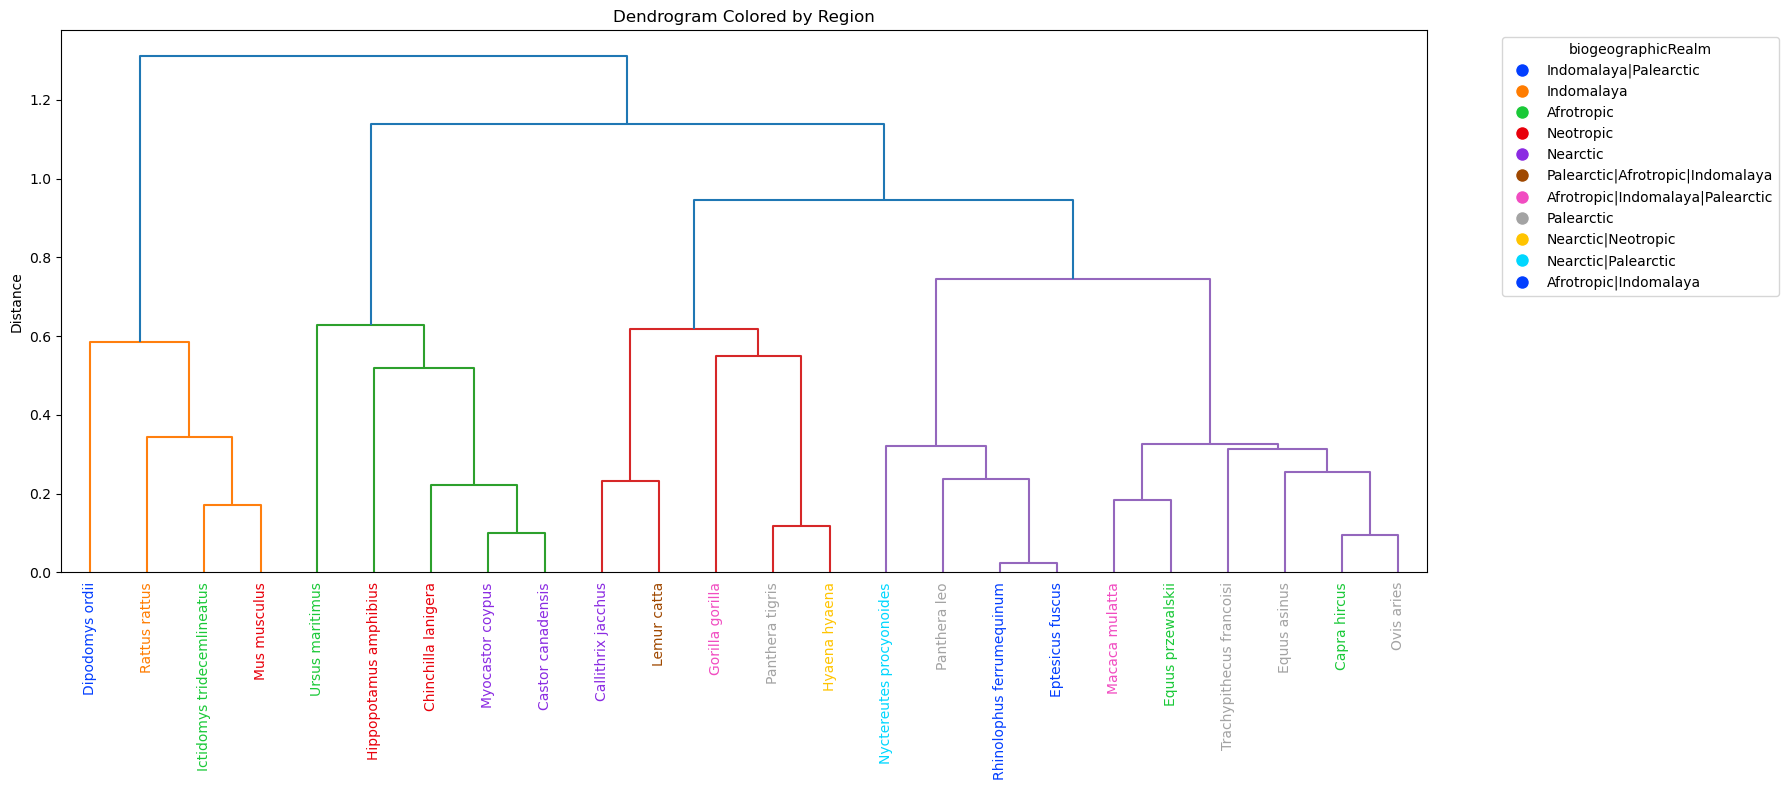

In [176]:
# --- Plot Dendrograms Colored by Region and Status ---
plot_colored_dendrogram('biogeographicRealm', "Dendrogram Colored by Region",palette_name="bright")


In [147]:
# --- Assign Clusters (Optional) ---
threshold = 0.7 * max(linkage_matrix[:, 2])
metadata['cluster_hier'] = fcluster(linkage_matrix, t=threshold, criterion='distance')


# --- Contingency Tables ---
print("\nContingency Table: Cluster vs Region")
print(pd.crosstab(metadata['cluster_hier'], metadata['biogeographicRealm']))



Contingency Table: Cluster vs Region
biogeographicRealm  Afrotropic  Afrotropic|Indomalaya  \
cluster_hier                                            
1                            0                      0   
2                            1                      0   
3                            2                      0   
4                            1                      1   

biogeographicRealm  Afrotropic|Indomalaya|Palearctic  Indomalaya  \
cluster_hier                                                       
1                                                  1           0   
2                                                  0           0   
3                                                  1           0   
4                                                  0           1   

biogeographicRealm  Indomalaya|Palearctic  Nearctic  Nearctic|Neotropic  \
cluster_hier                                                              
1                                       0         2         

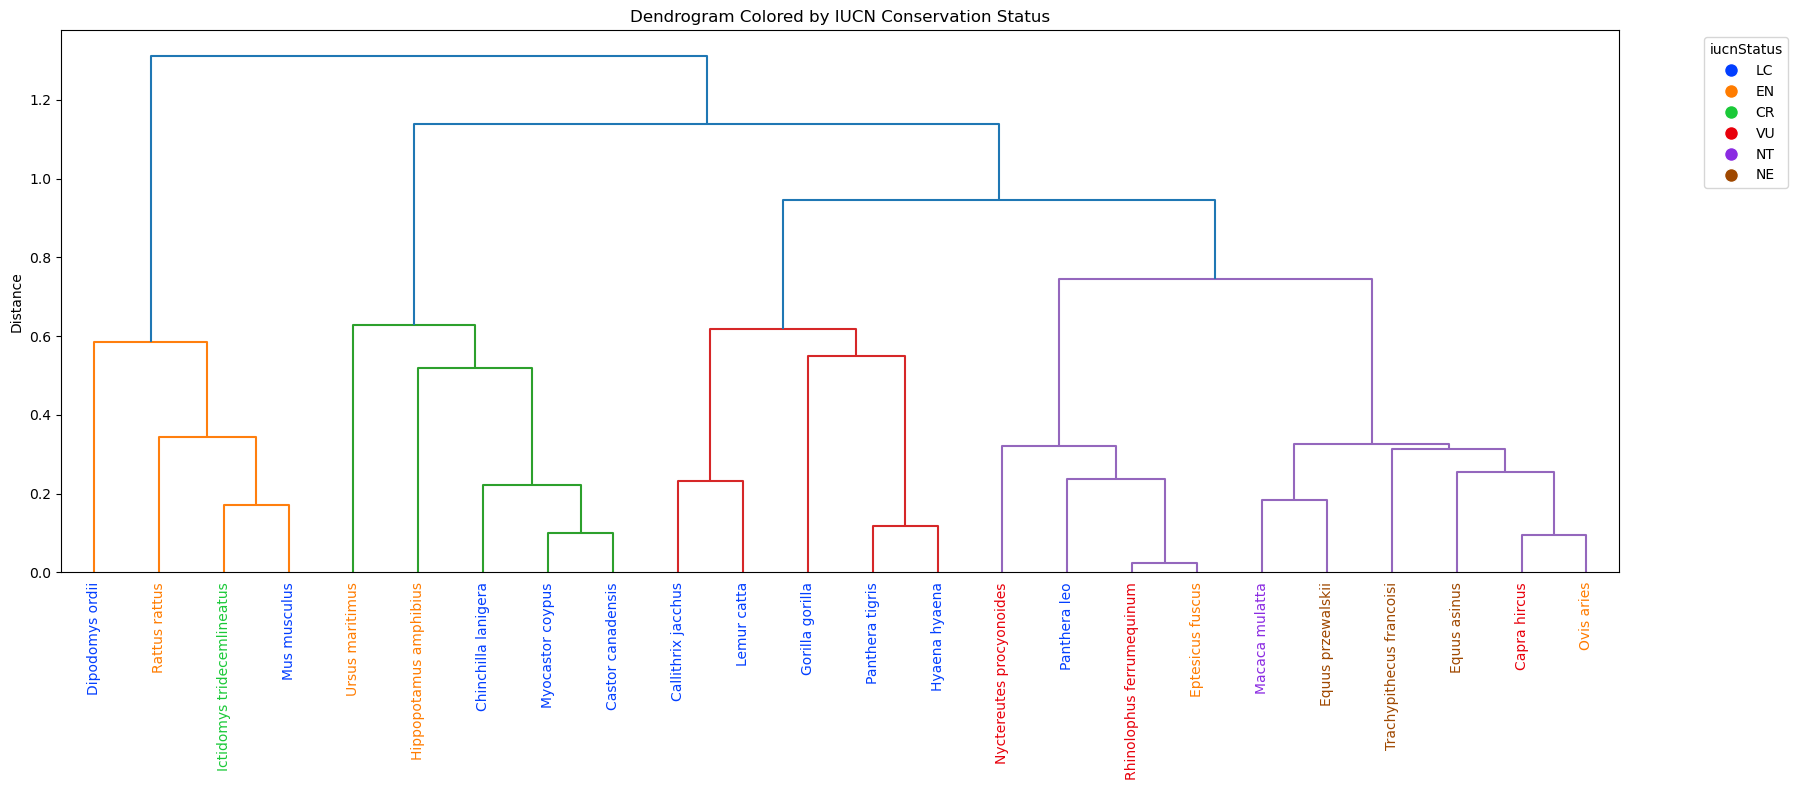

In [175]:

plot_colored_dendrogram('iucnStatus', "Dendrogram Colored by IUCN Conservation Status", palette_name="bright")


In [149]:
print("\nContingency Table: Cluster vs Conservation Status")
print(pd.crosstab(metadata['cluster_hier'], metadata['iucnStatus']))


Contingency Table: Cluster vs Conservation Status
iucnStatus    CR  EN  LC  NE  NT  VU
cluster_hier                        
1              0   0   4   0   0   0
2              0   1   2   0   0   2
3              1   2   1   0   1   0
4              0   2   4   3   0   1


In [150]:


# You already have `X_scaled` and `metadata['cluster_hier']`
score = silhouette_score(X_scaled, metadata['cluster_hier'], metric='cosine')
print(f"Silhouette Score (Cosine Distance): {score:.4f}")


Silhouette Score (Cosine Distance): 0.4511


### **multi-input CNN model**

In [151]:
GENES = ['apob', 'brca1', 'coi', 'cytb', 'rag1']
DATA_DIR = r"C:\Users\Ankush Ahuja\Desktop\Saint peters\DS-630\Peoject1\onehot"
SEQ_PATHS = [os.path.join(DATA_DIR, f"{gene}_onehot.npy") for gene in GENES]


In [152]:
NUM_CLASSES = 5
BATCH_SIZE = 8
EPOCHS = 15
LEARNING_RATE = 1e-3

In [153]:
class GeneCNN(nn.Module):
    def __init__(self, input_channels=4, output_dim=64):
        super(GeneCNN, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))       # (B, 32, L)
        x = F.relu(self.conv2(x))       # (B, 64, L)
        x = self.pool(x).squeeze(-1)    # (B, 64)
        return self.fc(x)               # (B, output_dim)

class MetadataEncoder(nn.Module):
    def __init__(self, input_dim=3, output_dim=64):
        super(MetadataEncoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [154]:
class MultiGeneHybridModel(nn.Module):
    def __init__(self, gene_output_dim=64, meta_output_dim=64, num_classes=NUM_CLASSES):
        super(MultiGeneHybridModel, self).__init__()
        self.gene_cnns = nn.ModuleList([GeneCNN(output_dim=gene_output_dim) for _ in range(5)])
        self.metadata_encoder = MetadataEncoder(input_dim=3, output_dim=meta_output_dim)

        total_feature_dim = 5 * gene_output_dim + meta_output_dim
        self.classifier = nn.Sequential(
            nn.Linear(total_feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, gene_inputs, meta_input):
        gene_embeds = [cnn(x) for cnn, x in zip(self.gene_cnns, gene_inputs)]  # list of (B, D)
        genes_concat = torch.cat(gene_embeds, dim=1)  # (B, 5*D)
        meta_emb = self.metadata_encoder(meta_input)  # (B, M)
        combined = torch.cat((genes_concat, meta_emb), dim=1)  # (B, 5D + M)
        return self.classifier(combined)


In [155]:
class MultiGeneDataset(Dataset):
    def __init__(self, gene_arrays, metadata_df, labels):
        self.gene_tensors = [torch.tensor(g.transpose(0, 2, 1), dtype=torch.float32) for g in gene_arrays]
        self.length = self.gene_tensors[0].shape[0]

        scaler = StandardScaler()
        meta = scaler.fit_transform(metadata_df[['latitude', 'longitude', 'iucn_ordinal']])
        self.meta = torch.tensor(meta, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        genes = [g[idx] for g in self.gene_tensors]
        meta = self.meta[idx]
        label = self.labels[idx]
        return genes, meta, label


In [156]:
def train_model(model, dataloader, epochs=EPOCHS, lr=LEARNING_RATE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for gene_inputs, meta_input, labels in dataloader:
            optimizer.zero_grad()
            preds = model(gene_inputs, meta_input)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")


In [157]:
if __name__ == "__main__":
    # Load gene one-hot arrays
    gene_arrays = [np.load(path) for path in SEQ_PATHS]

    # Ensure all genes have same number of samples
    assert all(g.shape[0] == gene_arrays[0].shape[0] for g in gene_arrays)

    # Load metadata
    df_meta = pd.read_csv("updated_species_with_latlong.csv")

    # Load pairwise distance matrix and generate KMeans labels
    dist_df = pd.read_csv("square_distance_matrix.csv", index_col=0)
    dist_matrix = dist_df.values
    kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=42)
    labels = kmeans.fit_predict(dist_matrix)

    # Dataset + DataLoader
    dataset = MultiGeneDataset(gene_arrays, df_meta, labels)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Train model
    model = MultiGeneHybridModel()
    train_model(model, dataloader)

Epoch 1/15 | Loss: 4.6986
Epoch 2/15 | Loss: 4.1195
Epoch 3/15 | Loss: 3.8168
Epoch 4/15 | Loss: 3.9270
Epoch 5/15 | Loss: 3.9029
Epoch 6/15 | Loss: 3.7809
Epoch 7/15 | Loss: 3.6801
Epoch 8/15 | Loss: 3.6861
Epoch 9/15 | Loss: 3.6463
Epoch 10/15 | Loss: 3.6088
Epoch 11/15 | Loss: 3.5251
Epoch 12/15 | Loss: 3.5105
Epoch 13/15 | Loss: 3.4438
Epoch 14/15 | Loss: 3.4021
Epoch 15/15 | Loss: 3.3345


In [158]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for gene_inputs, meta_input, labels in dataloader:
            preds = model(gene_inputs, meta_input)
            _, predicted_labels = torch.max(preds, dim=1)
            all_preds.append(predicted_labels.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    # Calculate performance metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

# After training the model
evaluate_model(model, dataloader)


Accuracy: 0.5000
Precision: 0.3958
Recall: 0.5000
F1 Score: 0.4404


C:\Users\Ankush Ahuja\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [167]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(metadata['family'], labels)
nmi = normalized_mutual_info_score(metadata['family'], labels)

print(f"ARI: {ari:.4f}, NMI: {nmi:.4f}")


ARI: -0.0119, NMI: 0.5029


In [161]:


# Read and process the tree using Bio.Phylo
tree = Phylo.read("phylogenetic_tree.nwk", "newick")


for clade in tree.get_terminals():
    if clade.name:
        clade.name = clade.name[:30] + '...' if len(clade.name) > 30 else clade.name


for clade in tree.get_nonterminals():
    clade.name = re.sub(r'ott\d+', '', clade.name)  

# Visualize the tree
Phylo.draw_ascii(tree)


                      ,,,,, _,,,,, _ Mus_musculus_ott542509
          ,,, _,,,,, _|
          |           |,,,, _,,,,, _,,,, _ Rattus_rattus_ott271571
         ,|
         ||,, _,,,,, _ Dipodomys_ordii_ott917328
         |||
        ,| |, _ Castor_canadensis_ott886085
        ||
        ||     ,,,,, _,,, Myocastor_coypus_ott169715
  ,,,, _||,,, _|
  |     |      |,,,, Chinchilla_lanigera_ott173054
  |     |
  |     |,,,, _,,,,, _,,,,, _ Ictidomys_tridecemlineatus_ott...
  |
 ,|            ,,,,, _,,,,, Trachypithecus_francoisi_ott43...
 ||        ,, _|
 ||     ,,,|   |,,,, _,,, Macaca_mulatta_ott689650
 ||     |  |
 ||  , _|  |, _,,,,, _, Gorilla_gorilla_ott417965
 ||  |  |
 ||,,|  |,,,, _,,,,, _,, Callithrix_jacchus_ott1015223
 |   |
 |   | _,,,,, _, Lemur_catta_ott913930
 |
 |                        , _,,,,, _,, Capra hircus (species in domai...
_|          , _,,,,, _,,,,|
 |       ,,,|             | _, Ovis_aries_ott70819
 |       |  |
 |  ,, _,|  | _,,,, Hippopotamus_amphibius_ott51